<a href="https://colab.research.google.com/github/amanmd07/2520030190_ML/blob/master/PROJECT/india_crop_yield_2020_2026_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np

In [14]:
import pandas as pd
import seaborn as sns

In [15]:
# Load the crop yield dataset
from pandas import read_csv
df=read_csv("/content/india_crop_yield_2020_2026.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())


Dataset loaded successfully.
Shape: (17400, 10)


,Year,State,Crop,Season,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,2009,Madhya Pradesh,Sweet potato,Whole Year,3497.00,20803.00,904.1,544902.54,594.49,6.020000
1,2025,Madhya Pradesh,Sunflower,Kharif,1088.98,1198.25,1073.3,143924.63,324.80,1.100347
2,2001,Nagaland,Jute,Kharif,300.00,300.00,1532.0,30639.00,78.00,0.986667
3,2004,Jharkhand,Sugarcane,Whole Year,542.97,13958.00,1149.2,58825.37,114.02,25.710000
4,2026,Uttar Pradesh,Linseed,Rabi,30957.93,18904.19,666.0,5209717.92,8528.93,0.610641


In [16]:
# Numerical vs Categorical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object', 'category', 'bool']).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['Year', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']
Categorical Features: ['State', 'Crop', 'Season']


In [17]:
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numerical_cols].corr()

In [18]:
# Print matrix to terminal
print("\n--- Correlation Matrix ---")
print(corr_matrix)


--- Correlation Matrix ---
                     Year      Area  Production  Annual_Rainfall  Fertilizer  \
Year             1.000000 -0.031966    0.002326         0.037794    0.002705   
Area            -0.031966  1.000000    0.043036        -0.158387    0.919463   
Production       0.002326  0.043036    1.000000         0.023847    0.045954   
Annual_Rainfall  0.037794 -0.158387    0.023847         1.000000   -0.124397   
Fertilizer       0.002705  0.919463    0.045954        -0.124397    1.000000   
Pesticide        0.003983  0.904470    0.045307        -0.123033    0.972926   
Yield           -0.000824  0.002241    0.616972         0.013824    0.006612   

                 Pesticide     Yield  
Year              0.003983 -0.000824  
Area              0.904470  0.002241  
Production        0.045307  0.616972  
Annual_Rainfall  -0.123033  0.013824  
Fertilizer        0.972926  0.006612  
Pesticide         1.000000  0.006485  
Yield             0.006485  1.000000  


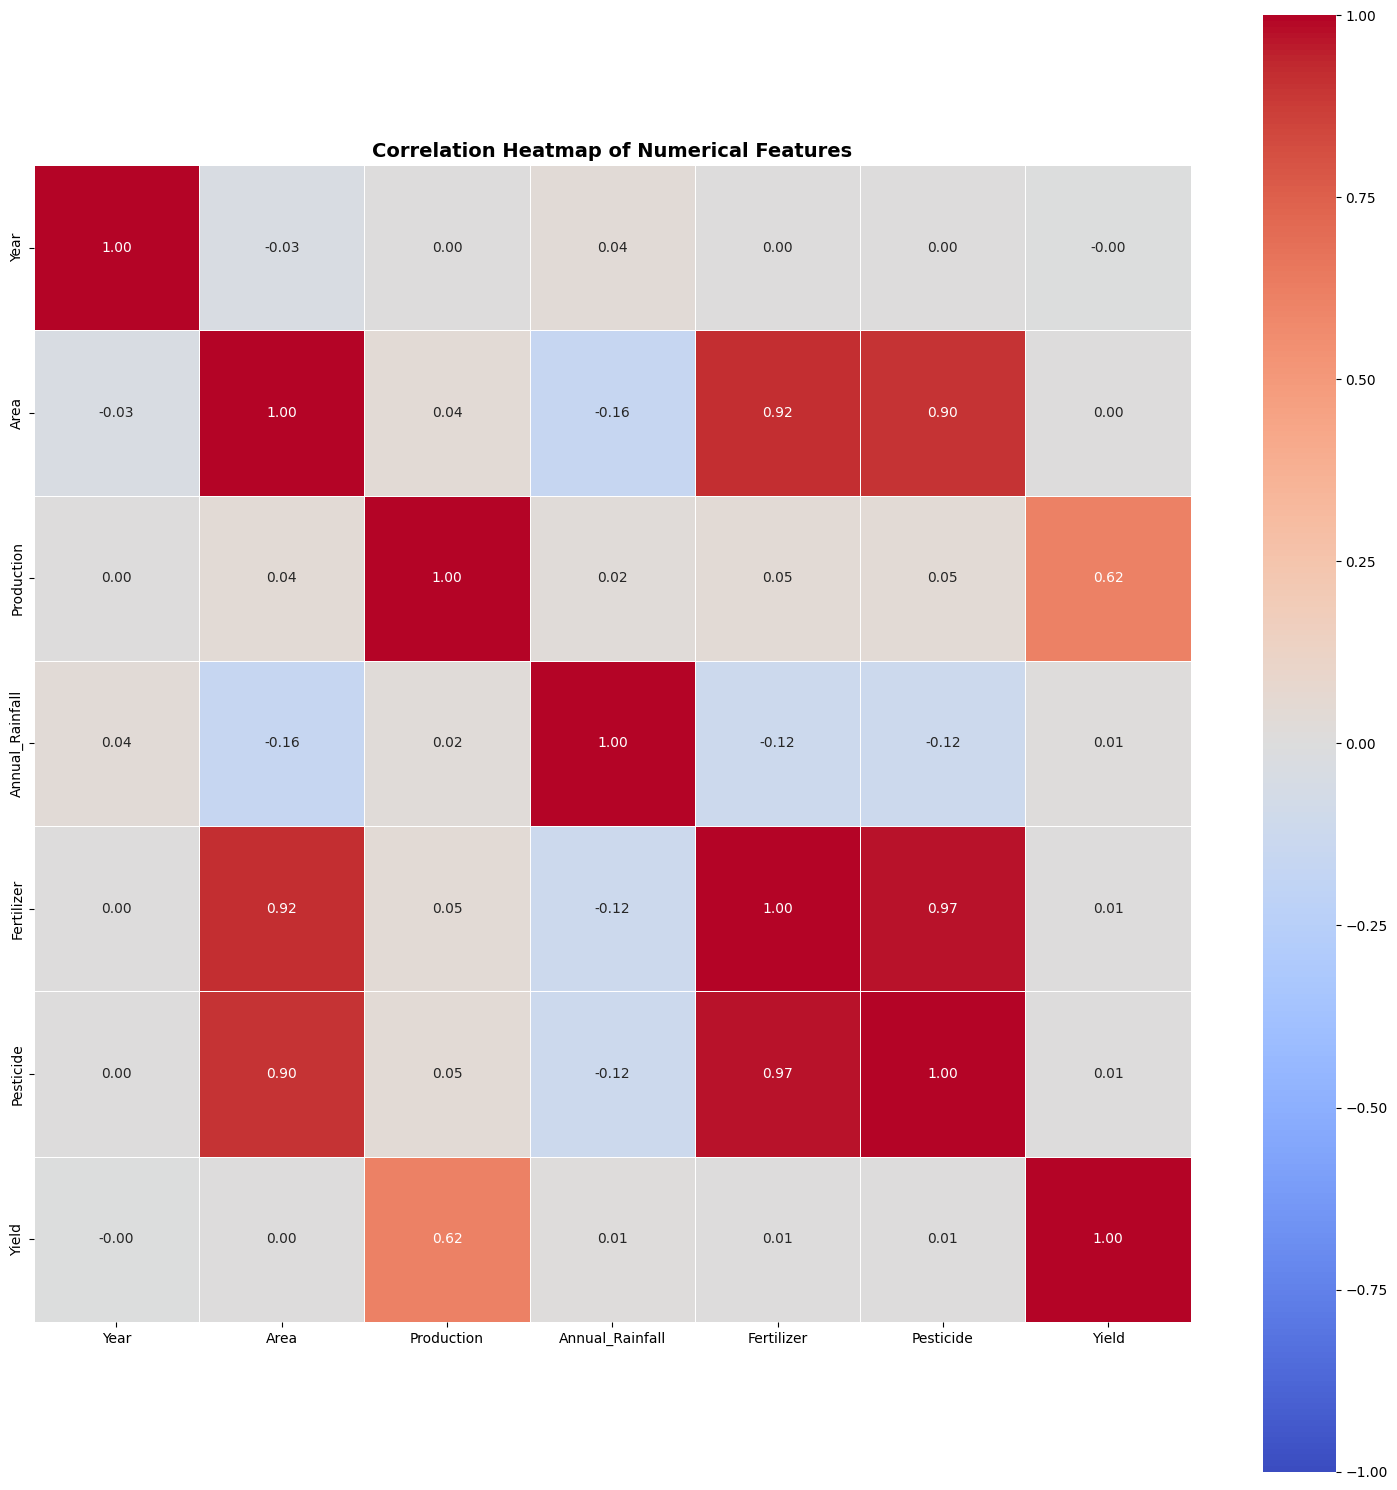

In [19]:
# Create Heatmap
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [20]:
# Export Heatmap
import os
output_dir = "/content/"
heatmap_path = os.path.join(output_dir, "correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")
plt.close()
print(f"Exported heatmap to: {heatmap_path}")

Exported heatmap to: /content/correlation_heatmap.png


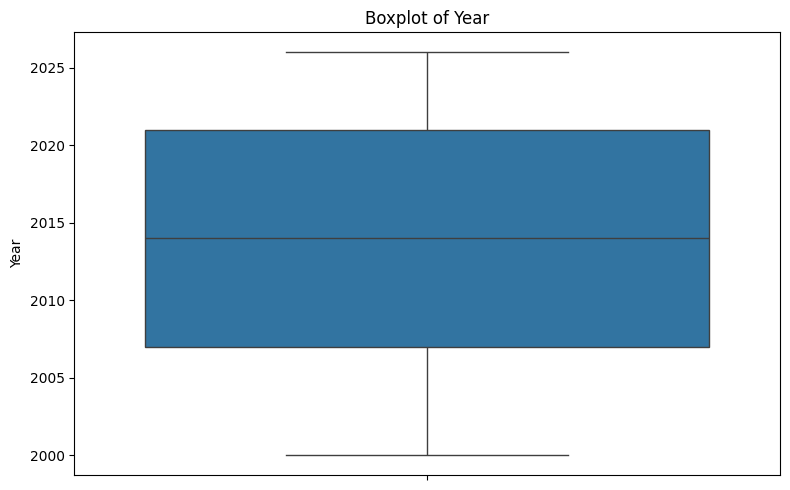

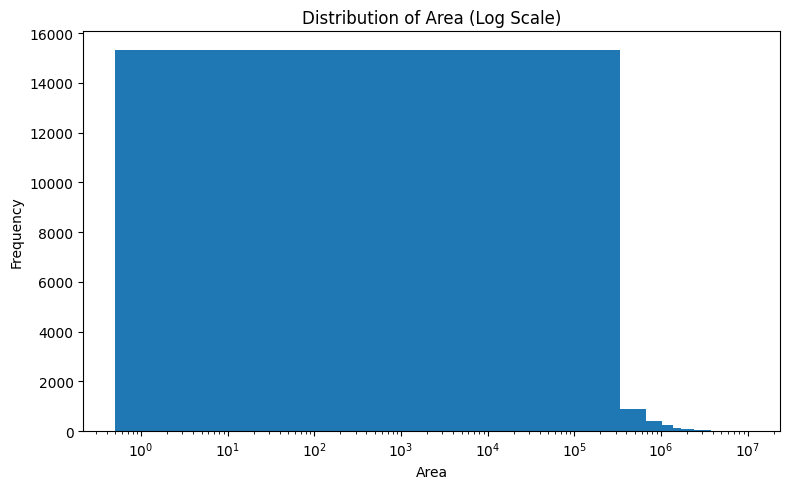

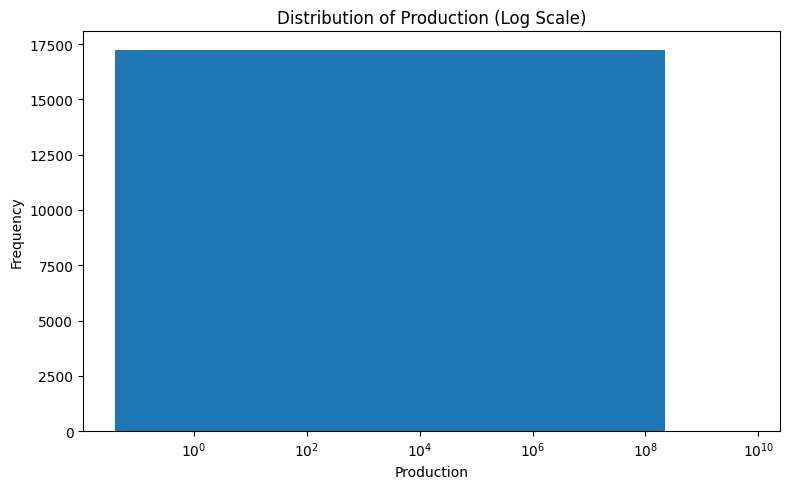

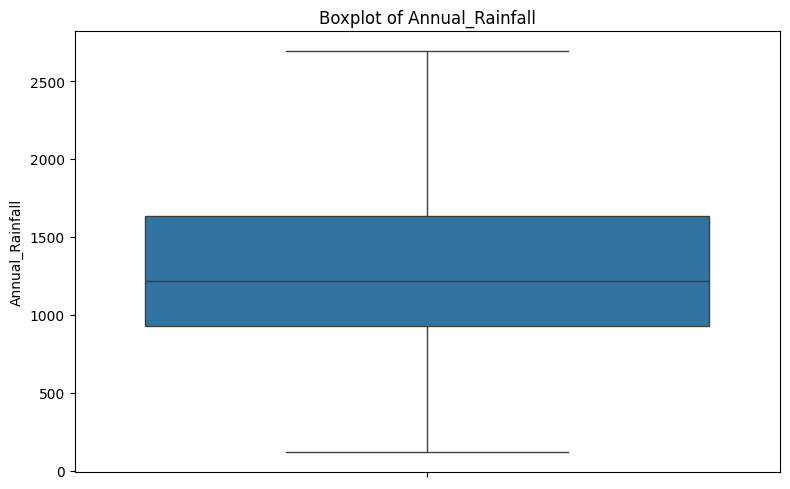

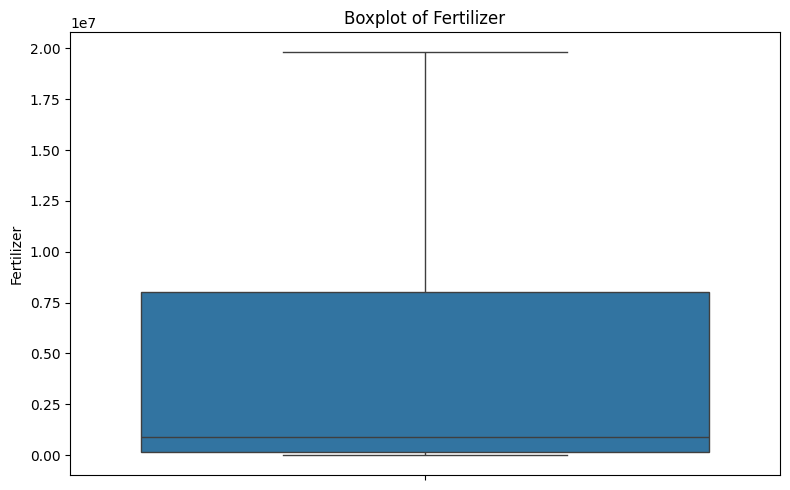

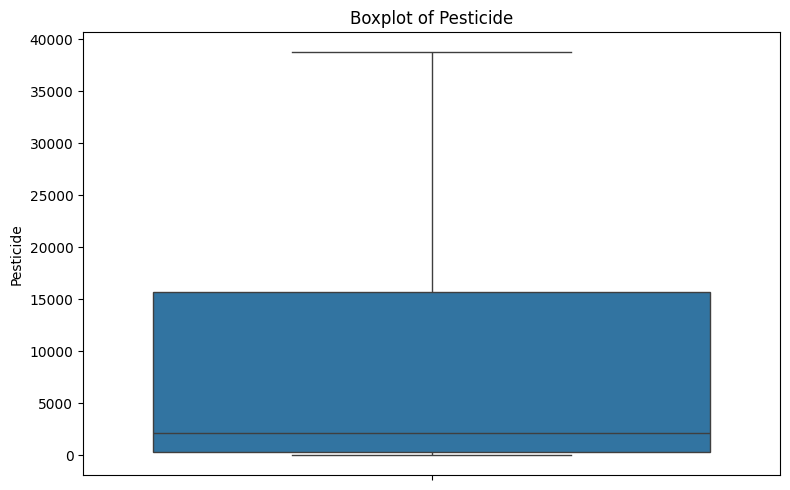

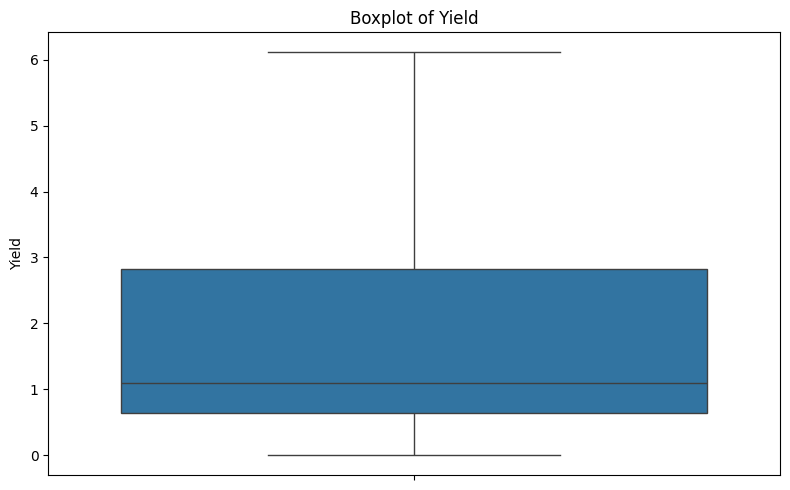

In [21]:
# Distribution graphs for numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numerical_cols:
    if col in ['Area', 'Production']:
        # Area and Production are highly skewed, so a log-scale histogram is clearer.
        plt.figure(figsize=(8, 5))
        values = df[col].dropna()
        values = values[values > 0]
        plt.hist(values, bins=30)
        plt.xscale('log')
        plt.title(f'Distribution of {col} (Log Scale)')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()
    else:
        # Compact numerical features are shown using a boxplot.
        plt.figure(figsize=(8, 5))
        sns.boxplot(y=df[col], showfliers=False)
        plt.title(f'Boxplot of {col}')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

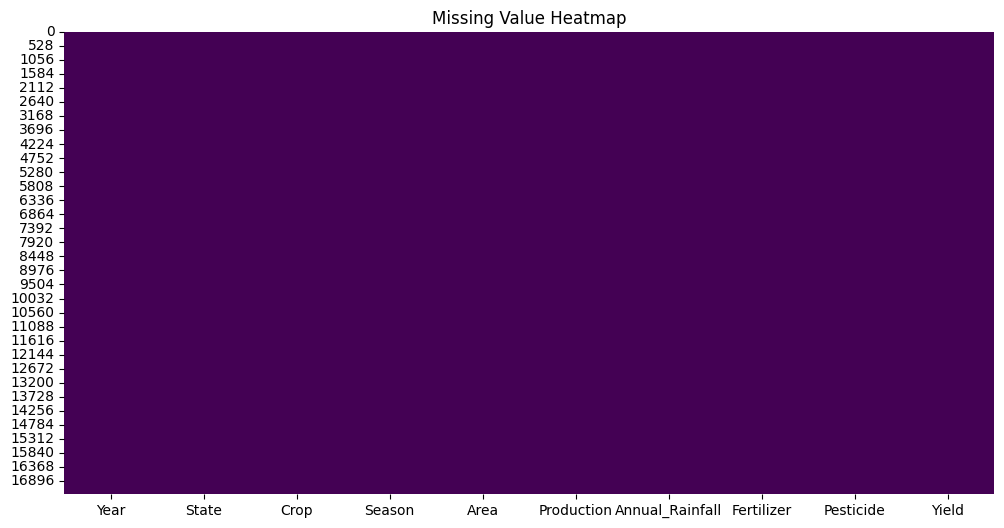

In [22]:
import matplotlib.pyplot as plt
fig1=plt.figure(figsize=(12,6))

sns.heatmap(
         df.isnull(),
        cbar=False,
         cmap="viridis"
)

plt.title("Missing Value Heatmap")

plt.show()

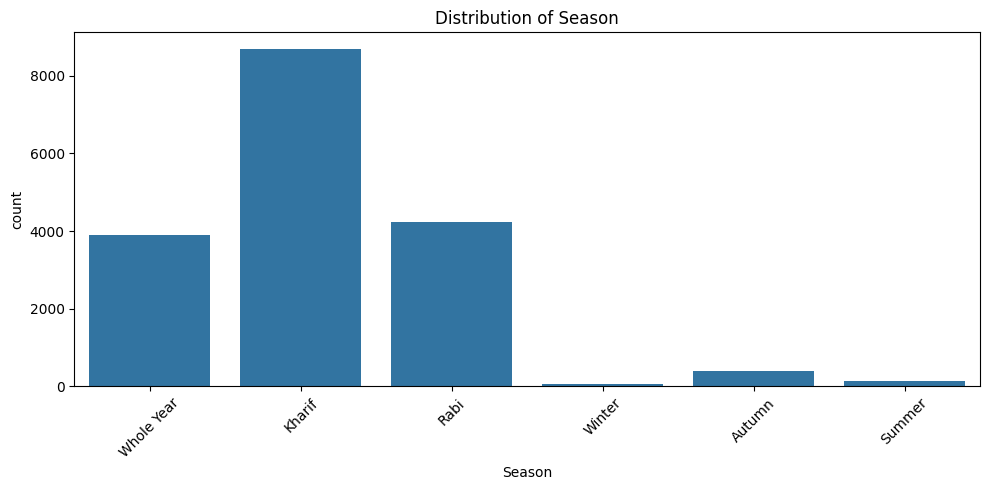

In [23]:
# Categorical feature analysis
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
for col in categorical_cols:
    if df[col].nunique() <= 20:
        plt.figure(figsize=(10,5))
        sns.countplot(data=df, x=col)
        plt.title(f'Distribution of {col}')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

In [24]:
# Correlation of Numerical Features with Yield
if 'Yield' in corr_matrix.columns:
    yield_corr = corr_matrix['Yield'].sort_values(ascending=False)
    print(yield_corr)
else:
    print("Yield column not found in the dataset.")

Yield              1.000000
Production         0.616972
Annual_Rainfall    0.013824
Fertilizer         0.006612
Pesticide          0.006485
Area               0.002241
Year              -0.000824
Name: Yield, dtype: float64


In [25]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import seaborn as sns

with PdfPages("EDA_Report.pdf") as pdf:

    # Missing Value Heatmap
    fig1 = plt.figure(figsize=(12, 6))
    sns.heatmap(df.isnull(), cbar=False)
    plt.title("Missing Value Heatmap")
    plt.tight_layout()
    pdf.savefig(fig1)
    plt.close(fig1)

    # Correlation Heatmap
    fig2 = plt.figure(figsize=(12, 10))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap="coolwarm",
        fmt=".2f"
    )
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    pdf.savefig(fig2)
    plt.close(fig2)

    # Numerical Feature Graphs
    for col in numerical_cols:

        fig = plt.figure(figsize=(8, 5))

        if col == "Area" or col == "Production":

            values = df[col].dropna()
            values = values[values > 0]

            plt.hist(values, bins=30)
            plt.xscale("log")
            plt.title(f"Distribution of {col} (Log Scale)")
            plt.xlabel(col)
            plt.ylabel("Frequency")

        else:

            sns.boxplot(
                y=df[col],
                showfliers=False
            )
            plt.title(f"Boxplot of {col}")
            plt.ylabel(col)

        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

print("EDA Report saved successfully.")


EDA Report saved successfully.
